# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)# YOUR CODE HERE

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

<b>Answer:</b>
1. The Census Income Data was chosen for this capstone lab.
2. The label is income_binary. It is used to predict whether a person’s annual income is greater than $50$K or less than or equal to $50$K. More than $50$K is represented as 1, and less than or equal to $50$K is represented as 0 in binary form.
3. Features that are planned to be used are the following:
    * age
    * workclass
    * education-num
    * marital-status
    * capital-gain
    * capital-loss
    * hours-per-week
    * occupation
    * relationship
4. This problem matters since CDFI currently determines program eligibility through a manual intake process in which case managers review each applicant's employment status, education level, hours worked, and other background information before making a recommendation, which is time consuming especially when the focus of EquiLend is to provide help clients make faster, more consistent decisions about financial product. This prediction through label can help them to review to categorize the client/applicant based on income and other features into catgories like greater or equal to $50$k and less that $50$k making the to identify individuals likely to be earning above or below a key income threshold, information central to determining eligibility for several of its programs, making process faster, and decisions.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

In [4]:
# YOUR CODE HERE
df.shape

(32561, 15)

In [5]:
unique_income_binary_check = df['income_binary'].unique()
unique_income_binary_check

array(['<=50K', '>50K'], dtype=object)

In [6]:
counts = df['income_binary'].value_counts()
counts

<=50K    24720
>50K      7841
Name: income_binary, dtype: int64

In [7]:
counts['<=50K']/sum(counts.values)

0.7591904425539756

In [8]:
counts['>50K']/sum(counts.values)

0.2408095574460244

<AxesSubplot:xlabel='income_binary', ylabel='Count'>

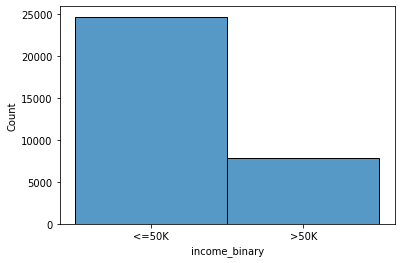

In [9]:
sns.histplot(data=df, x="income_binary") #https://seaborn.pydata.org/generated/seaborn.histplot.html

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [10]:
# YOUR CODE HERE
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


In [11]:
df.dtypes

age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex_selfID         object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income_binary      object
dtype: object

In [12]:
df.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
count,32399.000000,30725,3.256100e+04,32561,32561.000000,32561,30718,32561,32561,32561,32561.000000,32561.000000,32236.000000,31978,32561
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Non-Female,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.589216,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,615.907773,87.303830,40.450428,NaN,NaN
std,13.647862,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,2420.191974,402.960219,12.353748,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [13]:
df.nunique()

age                  73
workclass             8
fnlwgt            21648
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex_selfID            2
capital-gain        106
capital-loss         92
hours-per-week       94
native-country       41
income_binary         2
dtype: int64

In [14]:
dict_type = {}
for cols in df.columns:
    dict_type[cols] = pd.api.types.infer_dtype(df[cols])
dict_type

{'age': 'floating',
 'capital-gain': 'integer',
 'capital-loss': 'integer',
 'education': 'string',
 'education-num': 'integer',
 'fnlwgt': 'integer',
 'hours-per-week': 'floating',
 'income_binary': 'string',
 'marital-status': 'string',
 'native-country': 'string',
 'occupation': 'string',
 'race': 'string',
 'relationship': 'string',
 'sex_selfID': 'string',
 'workclass': 'string'}

In [15]:
#handling missing values
df.isnull().values.any()

True

In [16]:
df.isnull().head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [17]:
nan_count = np.sum(df.isnull(), axis=0)
nan_count

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

In [18]:
nan_detected = nan_count != 0 
col_names = nan_count[nan_detected].index 
print(col_names)

nan_cols = list(col_names)
print(nan_cols)

Index(['age', 'workclass', 'occupation', 'hours-per-week', 'native-country'], dtype='object')
['age', 'workclass', 'occupation', 'hours-per-week', 'native-country']


In [19]:
nan_col_types = df[nan_cols].dtypes
nan_col_types

age               float64
workclass          object
occupation         object
hours-per-week    float64
native-country     object
dtype: object

In [20]:
print(df['workclass'].unique())
print(df['occupation'].unique())
print(df['native-country'].unique())

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Without-pay' 'Never-worked']
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
['United-States' 'Cuba' 'Jamaica' 'India' nan 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' 'Canada' 'Germany' 'Iran'
 'Philippines' 'Italy' 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador'
 'Laos' 'Taiwan' 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador'
 'France' 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary' 'Holand-Netherlands']


In [21]:
is_int_or_float = (df.dtypes == 'int64') | (df.dtypes == 'float64')
is_int_or_float

age                True
workclass         False
fnlwgt             True
education         False
education-num      True
marital-status    False
occupation        False
relationship      False
race              False
sex_selfID        False
capital-gain       True
capital-loss       True
hours-per-week     True
native-country    False
income_binary     False
dtype: bool

In [22]:
to_impute = nan_detected & is_int_or_float
to_impute

age                True
workclass         False
fnlwgt            False
education         False
education-num     False
marital-status    False
occupation        False
relationship      False
race              False
sex_selfID        False
capital-gain      False
capital-loss      False
hours-per-week     True
native-country    False
income_binary     False
dtype: bool

In [23]:
df.columns[to_impute]

Index(['age', 'hours-per-week'], dtype='object')

In [24]:
to_impute_selected = ['age', 'hours-per-week']

In [25]:
for cols in to_impute_selected:
    original_column_name = cols + '_na'
    df[original_column_name] = df[cols].isnull()

In [26]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary,age_na,hours-per-week_na
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K,False,False
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K,False,False
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K,False,False
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K,False,False
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K,False,False


In [27]:
# replace the missing values with mean values of the col
for cols in to_impute_selected:
    mean_value = df[cols].mean()
    df[cols].fillna(value=mean_value, inplace=True)

In [28]:
for colname in to_impute_selected:
    print("{} missing values count :{}".format(colname, np.sum(df[colname].isnull(), axis = 0)))

age missing values count :0
hours-per-week missing values count :0


In [29]:
df['age'].unique()

array([39.        , 50.        , 38.        , 53.        , 28.        ,
       37.        , 49.        , 52.        , 31.        , 42.        ,
       30.        , 23.        , 32.        , 40.        , 34.        ,
       25.        , 43.        , 54.        , 35.        , 59.        ,
       56.        , 19.        , 20.        , 45.        , 22.        ,
       48.        , 21.        , 24.        , 57.        , 44.        ,
       41.        , 29.        , 38.58921572, 18.        , 47.        ,
       46.        , 36.        , 79.        , 27.        , 67.        ,
       33.        , 76.        , 17.        , 55.        , 61.        ,
       70.        , 64.        , 71.        , 68.        , 66.        ,
       51.        , 58.        , 26.        , 60.        , 90.        ,
       75.        , 65.        , 77.        , 62.        , 63.        ,
       80.        , 72.        , 74.        , 69.        , 73.        ,
       81.        , 78.        , 88.        , 82.        , 83.  

In [30]:
df['hours-per-week'].unique()

array([40.        , 13.        , 16.        , 45.        , 50.        ,
       80.        , 30.        , 35.        , 40.45042809, 60.        ,
       20.        , 52.        , 44.        , 15.        , 25.        ,
       38.        , 43.        , 55.        , 48.        , 58.        ,
       32.        , 70.        ,  2.        , 22.        , 56.        ,
       28.        , 36.        , 24.        , 46.        , 42.        ,
       12.        , 65.        ,  1.        , 10.        , 34.        ,
       75.        , 98.        , 33.        , 54.        ,  8.        ,
        6.        , 64.        , 19.        , 18.        , 72.        ,
        5.        ,  9.        , 47.        , 37.        , 21.        ,
       26.        , 14.        ,  4.        , 59.        ,  7.        ,
       99.        , 53.        , 39.        , 62.        , 41.        ,
       57.        , 78.        , 90.        , 66.        , 11.        ,
       49.        , 84.        ,  3.        , 17.        , 68.  

In [31]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary,age_na,hours-per-week_na
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K,False,False
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K,False,False
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K,False,False
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K,False,False
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K,False,False


In [32]:
categorical_var = ["workclass", "native-country", "occupation"]
for col in categorical_var:
    df[col] = df[col].fillna("Unknown")

In [33]:
df.isnull().sum()

age                  0
workclass            0
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation           0
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country       0
income_binary        0
age_na               0
hours-per-week_na    0
dtype: int64

In [34]:
df.isnull().sum().sum()

0

<AxesSubplot:xlabel='age'>

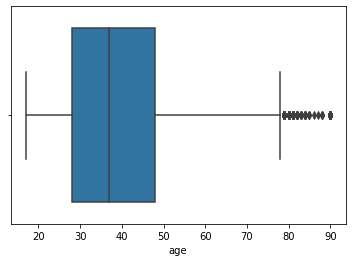

In [35]:
sns.boxplot(x=df["age"])

<AxesSubplot:xlabel='hours-per-week'>

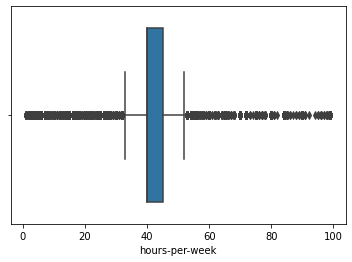

In [36]:
sns.boxplot(x=df["hours-per-week"])

In [37]:
# finding and replacing outliers for num features
import scipy.stats as stats
df["age_winsorized"] = stats.mstats.winsorize(df['age'], limits=[0.01, 0.01])
df["hours-per-week_winsorized"] = stats.mstats.winsorize(df['hours-per-week'], limits=[0.01, 0.01])

In [38]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary,age_na,hours-per-week_na,age_winsorized,hours-per-week_winsorized
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K,False,False,39.0,40.0
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K,False,False,50.0,13.0
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K,False,False,38.0,40.0
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K,False,False,53.0,40.0
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K,False,False,28.0,40.0


In [39]:
age_difference = df["age"] - df["age_winsorized"]
age_difference.unique()

array([ 0.,  5.,  2., 16.,  1.,  3.,  6.,  7.,  4., 14.,  8.,  9., 10.,
       11., 12., 13.])

In [40]:
hours_difference = df["hours-per-week"] - df["hours-per-week_winsorized"]
hours_difference.unique()

array([ 0., -6., -7., 18., -2., -3., -4., -1., 19., 10.,  4., -5.,  5.,
        7.,  8.,  9., 17., 14., 16.,  2.,  6., 11.,  1., 12., 15.])

<AxesSubplot:xlabel='age'>

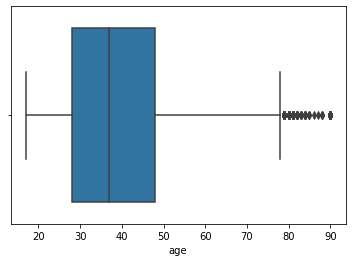

In [41]:
sns.boxplot(x=df["age"])

<AxesSubplot:xlabel='hours-per-week'>

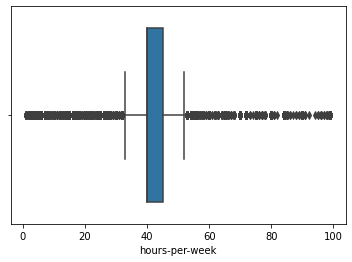

In [42]:
sns.boxplot(x=df["hours-per-week"])

In [43]:
df.isnull().any()

age                          False
workclass                    False
fnlwgt                       False
education                    False
education-num                False
marital-status               False
occupation                   False
relationship                 False
race                         False
sex_selfID                   False
capital-gain                 False
capital-loss                 False
hours-per-week               False
native-country               False
income_binary                False
age_na                       False
hours-per-week_na            False
age_winsorized               False
hours-per-week_winsorized    False
dtype: bool

In [44]:
df.dtypes

age                          float64
workclass                     object
fnlwgt                         int64
education                     object
education-num                  int64
marital-status                object
occupation                    object
relationship                  object
race                          object
sex_selfID                    object
capital-gain                   int64
capital-loss                   int64
hours-per-week               float64
native-country                object
income_binary                 object
age_na                          bool
hours-per-week_na               bool
age_winsorized               float64
hours-per-week_winsorized    float64
dtype: object

In [45]:
cat_features = ["workclass", "marital-status", "occupation", "relationship"]

In [46]:
df[cat_features].nunique()

workclass          9
marital-status     7
occupation        15
relationship       6
dtype: int64

In [47]:
for col in cat_features:
    print('-----')
    print(col)
    print(df[col].unique())
    print('------')

-----
workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Unknown' 'Self-emp-inc' 'Without-pay' 'Never-worked']
------
-----
marital-status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
------
-----
occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Unknown'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
------
-----
relationship
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
------


In [48]:
to_encode = list(df.select_dtypes(include=["object"]).columns)
to_encode

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex_selfID',
 'native-country',
 'income_binary']

In [49]:
df[to_encode].nunique()

workclass          9
education         16
marital-status     7
occupation        15
relationship       6
race               5
sex_selfID         2
native-country    42
income_binary      2
dtype: int64

In [50]:
to_encode_features = ["workclass", "marital-status", "relationship", "occupation"]
to_encode_features

['workclass', 'marital-status', 'relationship', 'occupation']

<AxesSubplot:xlabel='income_binary', ylabel='education-num'>

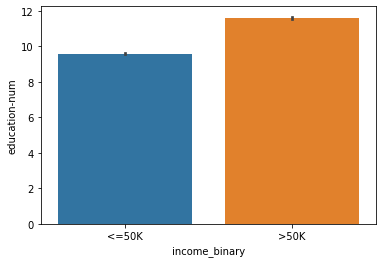

In [51]:
sns.barplot(data=df, x="income_binary", y="education-num")

In [52]:
for col in to_encode_features:
    for value in df[col].unique():
        col_name = col + "_" + str(value)
        df[col_name] = np.where(df[col]==value,1,0)
    df.drop(columns=col, inplace=True)
    df

In [53]:
df.head()

,age,fnlwgt,education,education-num,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,...,occupation_Sales,occupation_Craft-repair,occupation_Transport-moving,occupation_Farming-fishing,occupation_Machine-op-inspct,occupation_Tech-support,occupation_Unknown,occupation_Protective-serv,occupation_Armed-Forces,occupation_Priv-house-serv
0,39.0,77516,Bachelors,13,White,Non-Female,2174,0,40.0,United-States,...,0,0,0,0,0,0,0,0,0,0
1,50.0,83311,Bachelors,13,White,Non-Female,0,0,13.0,United-States,...,0,0,0,0,0,0,0,0,0,0
2,38.0,215646,HS-grad,9,White,Non-Female,0,0,40.0,United-States,...,0,0,0,0,0,0,0,0,0,0
3,53.0,234721,11th,7,Black,Non-Female,0,0,40.0,United-States,...,0,0,0,0,0,0,0,0,0,0
4,28.0,338409,Bachelors,13,Black,Female,0,0,40.0,Cuba,...,0,0,0,0,0,0,0,0,0,0


In [54]:
df["age_na"] = df["age_na"].astype(int)
df["hours-per-week_na"] = df["hours-per-week_na"].astype(int)

In [55]:
df["income_numeric"] = np.where(df["income_binary"] == ">50K", 1,0)

In [56]:
df["income_numeric"].value_counts()

0    24720
1     7841
Name: income_numeric, dtype: int64

In [57]:
corr_matrix = round(df.corr(), 5)
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,age_na,hours-per-week_na,age_winsorized,hours-per-week_winsorized,...,occupation_Craft-repair,occupation_Transport-moving,occupation_Farming-fishing,occupation_Machine-op-inspct,occupation_Tech-support,occupation_Unknown,occupation_Protective-serv,occupation_Armed-Forces,occupation_Priv-house-serv,income_numeric
age,1.00000,-0.07608,0.03669,0.12470,0.05748,0.06657,0.00000,-0.00004,0.99859,0.06967,...,0.01196,0.02649,0.03410,-0.01664,-0.01968,0.04212,0.00354,-0.01022,0.01370,0.23310
fnlwgt,-0.07608,1.00000,-0.04319,-0.00223,-0.01025,-0.01805,-0.00902,-0.00577,-0.07596,-0.01739,...,0.00846,0.00127,-0.03293,0.01276,0.00376,-0.00260,0.01657,0.00404,0.00728,-0.00946
education-num,0.03669,-0.04319,1.00000,0.16709,0.07992,0.14655,-0.00171,-0.00567,0.03797,0.15096,...,-0.14307,-0.11596,-0.10153,-0.15850,0.06070,-0.07877,0.00578,0.00020,-0.07164,0.33515
capital-gain,0.12470,-0.00223,0.16709,1.00000,-0.05514,0.10099,-0.00531,0.00498,0.12541,0.10415,...,-0.02341,-0.01757,-0.01174,-0.03498,-0.00506,-0.02538,-0.00478,-0.00423,-0.01151,0.34756
capital-loss,0.05748,-0.01025,0.07992,-0.05514,1.00000,0.05420,-0.00721,-0.00151,0.05776,0.05521,...,0.00109,-0.00328,-0.01067,-0.01626,0.00483,-0.01628,-0.00317,0.00505,-0.01108,0.15053
hours-per-week,0.06657,-0.01805,0.14655,0.10099,0.05420,1.00000,0.00225,0.00000,0.07096,0.99571,...,0.05699,0.07841,0.09477,0.00549,-0.01397,-0.16779,0.02790,0.00029,-0.04078,0.22840
age_na,0.00000,-0.00902,-0.00171,-0.00531,-0.00721,0.00225,1.00000,-0.00271,0.00028,0.00261,...,0.00475,-0.00595,-0.00240,0.01279,-0.00162,-0.00032,-0.00072,-0.00118,0.01461,-0.00409
hours-per-week_na,-0.00004,-0.00577,-0.00567,0.00498,-0.00151,0.00000,-0.00271,1.00000,-0.00031,0.00040,...,-0.00085,-0.00421,-0.00345,0.00517,0.00137,0.00883,0.00115,-0.00167,-0.00223,-0.00164
age_winsorized,0.99859,-0.07596,0.03797,0.12541,0.05776,0.07096,0.00028,-0.00031,1.00000,0.07411,...,0.01304,0.02739,0.03399,-0.01637,-0.01923,0.03951,0.00359,-0.01027,0.01329,0.23657
hours-per-week_winsorized,0.06967,-0.01739,0.15096,0.10415,0.05521,0.99571,0.00261,0.00040,0.07411,1.00000,...,0.05929,0.07840,0.09077,0.00655,-0.01453,-0.16863,0.02732,0.00037,-0.04279,0.23454


In [58]:
corrs = df.corr()['income_numeric']
corrs

age                                     0.233097
fnlwgt                                 -0.009463
education-num                           0.335154
capital-gain                            0.347555
capital-loss                            0.150526
hours-per-week                          0.228397
age_na                                 -0.004095
hours-per-week_na                      -0.001635
age_winsorized                          0.236569
hours-per-week_winsorized               0.234536
workclass_State-gov                     0.014843
workclass_Self-emp-not-inc              0.030019
workclass_Private                      -0.078528
workclass_Federal-gov                   0.059372
workclass_Local-gov                     0.033091
workclass_Unknown                      -0.078198
workclass_Self-emp-inc                  0.139467
workclass_Without-pay                  -0.011681
workclass_Never-worked                 -0.008259
marital-status_Never-married           -0.318440
marital-status_Marri

In [59]:
corrs_sorted = corrs.sort_values(ascending=False)
corrs_sorted

income_numeric                          1.000000
marital-status_Married-civ-spouse       0.444696
relationship_Husband                    0.401035
capital-gain                            0.347555
education-num                           0.335154
age_winsorized                          0.236569
hours-per-week_winsorized               0.234536
age                                     0.233097
hours-per-week                          0.228397
occupation_Exec-managerial              0.214861
occupation_Prof-specialty               0.185866
capital-loss                            0.150526
workclass_Self-emp-inc                  0.139467
relationship_Wife                       0.123264
workclass_Federal-gov                   0.059372
workclass_Local-gov                     0.033091
workclass_Self-emp-not-inc              0.030019
occupation_Protective-serv              0.028118
occupation_Tech-support                 0.025696
occupation_Sales                        0.023688
workclass_State-gov 

In [60]:
exclude = ["income_numeric", "age", "hours-per-week", "fnlwgt"]
corrs = df.corr()["income_numeric"].drop(exclude, axis=0)
corrs_sort = corrs.sort_values(ascending=False)
corrs_sort

marital-status_Married-civ-spouse       0.444696
relationship_Husband                    0.401035
capital-gain                            0.347555
education-num                           0.335154
age_winsorized                          0.236569
hours-per-week_winsorized               0.234536
occupation_Exec-managerial              0.214861
occupation_Prof-specialty               0.185866
capital-loss                            0.150526
workclass_Self-emp-inc                  0.139467
relationship_Wife                       0.123264
workclass_Federal-gov                   0.059372
workclass_Local-gov                     0.033091
workclass_Self-emp-not-inc              0.030019
occupation_Protective-serv              0.028118
occupation_Tech-support                 0.025696
occupation_Sales                        0.023688
workclass_State-gov                     0.014843
marital-status_Married-AF-spouse        0.012061
hours-per-week_na                      -0.001635
age_na              

In [61]:
corrs_sort.head(10)

marital-status_Married-civ-spouse    0.444696
relationship_Husband                 0.401035
capital-gain                         0.347555
education-num                        0.335154
age_winsorized                       0.236569
hours-per-week_winsorized            0.234536
occupation_Exec-managerial           0.214861
occupation_Prof-specialty            0.185866
capital-loss                         0.150526
workclass_Self-emp-inc               0.139467
Name: income_numeric, dtype: float64

In [62]:
top2 = corrs_sort.head(2)
top_two_corr = list(top2.index)
top_two_corr

['marital-status_Married-civ-spouse', 'relationship_Husband']

In [63]:
df_corrs = df[["income_numeric"] + top_two_corr].copy()

In [64]:
df_corrs.head(10)

,income_numeric,marital-status_Married-civ-spouse,relationship_Husband
0,0,0,0
1,0,1,1
2,0,0,0
3,0,1,1
4,0,1,0
5,0,1,0
6,0,0,0
7,1,1,1
8,1,0,0
9,1,1,1


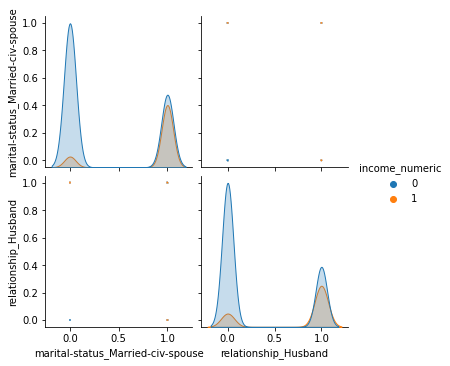

In [65]:
sns.pairplot(data=df_corrs, vars = top_two_corr, hue = 'income_numeric', plot_kws={'s':3})

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

<b> Key Findings from data exploration:</b>
* There is an imbalance where 75.9% of individuals make less than or equal to $50$K, and 24.1% make greater than $50$K in the dataset.
* Missing values were found in the hours-per-week, age, workclass, native-country, and occupation columns. The numerical missing values were filled with their column means, while the categorical missing values were filled with "Unknown".
* Winsorization was used for age and hours-per-week with a 1% limit to reduce the effect of outliers.
* One-hot encoding was done on the occupation, marital-status, workclass, and relationship columns.
* The education-num column was used, while race, sex_selfID, native-country, and fnlwgt were removed.. 
* From the correlation results and Seaborn plots, education, marital status, relationship, and employment factors are features that may help predict income.
* Logistic regression will be used for this analysis.
* Accuracy and F1 score will be used to evaluate performance because the dataset has class imbalance.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

<b> Answer:</b>
1. Some biases and ethical concerns that might be present in this dataset are:
    * This data is quite old, from 1994 Census which is historically old, and there existed no true equality among different demographic groups affecting different features related to demographic. 
    * Instead of using demographic related features like race, sex_selfID, native-country, other features were used like occupation, education, marital status, workclass, and relationship.

2. Incorrect predictions on this data by model can harm individuals with low income who need loans. Incorrect prediction of an individual who makes more than or equal to 50k and being placed in the incorrect category can impact prediction/decision for eligibilty to take loan and vice versa.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [66]:
# YOUR CODE HERE
# i did some of it in part 3 so adding small updates here, didn't realize sorry
excluded = ["age", "hours-per-week", "fnlwgt","education", "income_binary", "race", "sex_selfID", "native-country"]
df.drop(columns=excluded, inplace=True)

In [67]:
df.head()

,education-num,capital-gain,capital-loss,age_na,hours-per-week_na,age_winsorized,hours-per-week_winsorized,workclass_State-gov,workclass_Self-emp-not-inc,workclass_Private,...,occupation_Craft-repair,occupation_Transport-moving,occupation_Farming-fishing,occupation_Machine-op-inspct,occupation_Tech-support,occupation_Unknown,occupation_Protective-serv,occupation_Armed-Forces,occupation_Priv-house-serv,income_numeric
0,13,2174,0,0,0,39.0,40.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,13,0,0,0,0,50.0,13.0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,38.0,40.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,7,0,0,0,0,53.0,40.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,13,0,0,0,0,28.0,40.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [68]:
df.isnull().values.any()

False

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

<b> Answer </b>:
- Replaced the missing values in age and hours-per-week with their column means so that the rows could be kept, and created _na flag columns to record where the original value was missing. Furthermore, occupation, native-country, and workclass were filled with "Unknown" for the missing categorical features. The age and hours-per-week features were winsorized with a 1% limit to reduce the effect of extreme outliers.
- One-hot encoding was done on marital-status, occupation, workclass, and relationship. The label income_numeric was created, where >50K is 1 and <=50K is 0. I removed the original age and hours-per-week columns because their winsorized versions are being used instead, and kept education-num in place of the education column.
- Features such as fnlwgt, race, sex_selfID, and native-country were also removed due to relevance and ethical considerations.
- Logistic regression was used as the foundation model. The data was split into training and test sets, and the features were scaled after the split. The scaler was fitted on the training data and then applied to the test data.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [69]:
# Create labeled examples from the dataset
# YOUR CODE HERE
y = df['income_numeric']
X = df.drop(columns = 'income_numeric', axis =1)

In [70]:
print("Number of examples: " + str(X.shape[0]))
print("\nNumber of Features:" + str(X.shape[1]))
print(str(list(X.columns)))

Number of examples: 32561

Number of Features:44
['education-num', 'capital-gain', 'capital-loss', 'age_na', 'hours-per-week_na', 'age_winsorized', 'hours-per-week_winsorized', 'workclass_State-gov', 'workclass_Self-emp-not-inc', 'workclass_Private', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Unknown', 'workclass_Self-emp-inc', 'workclass_Without-pay', 'workclass_Never-worked', 'marital-status_Never-married', 'marital-status_Married-civ-spouse', 'marital-status_Divorced', 'marital-status_Married-spouse-absent', 'marital-status_Separated', 'marital-status_Married-AF-spouse', 'marital-status_Widowed', 'relationship_Not-in-family', 'relationship_Husband', 'relationship_Wife', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Other-relative', 'occupation_Adm-clerical', 'occupation_Exec-managerial', 'occupation_Handlers-cleaners', 'occupation_Prof-specialty', 'occupation_Other-service', 'occupation_Sales', 'occupation_Craft-repair', 'occupation_Transport-movi

In [71]:
# Create training and test sets out of the labeled examples 
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.10, random_state=1234)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(29304, 44)
(3257, 44)
(29304,)
(3257,)


In [72]:
# Train, test and evaluate your model
# YOUR CODE HERE
# to address the warning scaled data is added
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model_default = LogisticRegression(C=1.0, max_iter = 1000)
model_default.fit(X_train_scaled, y_train)

# prediction on test data usung predict proba method and prdict method
proba_predictions_default = model_default.predict_proba(X_test_scaled)[:,1]

class_label_predictions_default = model_default.predict(X_test_scaled)
acc_score_default = accuracy_score(y_test, class_label_predictions_default)
print('Accuracy score: {0}\n'.format(acc_score_default))
f1_default = f1_score(y_test, class_label_predictions_default, average = "binary")
print('F1 score: {0}\n'.format(f1_default))

Accuracy score: 0.8492477740251766

F1 score: 0.6559215136650316



In [73]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE
cs = [10**i for i in range(-5,5)]
param_grid = {'C': cs}
print(param_grid)
grid = GridSearchCV(model_default, param_grid, cv=5)
grid_search = grid.fit(X_train_scaled, y_train)

{'C': [1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]}


In [74]:
best_C = grid_search.best_params_['C']
best_C

0.1

In [75]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE
model_best = LogisticRegression(C=best_C, max_iter = 1000)
model_best.fit(X_train_scaled, y_train)
proba_predictions_best = model_best.predict_proba(X_test_scaled)[:, 1]
class_label_predictions_best = model_best.predict(X_test_scaled)
acc_score_best = accuracy_score(y_test, class_label_predictions_best)
print('Accuracy score: {0}\n'.format(acc_score_best))
f1_best = f1_score(y_test, class_label_predictions_best, average = "binary")
print('F1 score: {0}\n'.format(f1_best))

Accuracy score: 0.8495548050353086

F1 score: 0.6563814866760168



In [76]:
# Interpret your model's outputs 
# YOUR CODE HERE
# for logistic regression coefficients are used
# took some help on google to find how this part should be written
coefficient_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model_best.coef_[0]})
coefficient_df["Absolute_Coefficient"]  = coefficient_df["Coefficient"].abs()
coefficient_df = coefficient_df.sort_values(by="Absolute_Coefficient", ascending=False)
print(coefficient_df[["Feature", "Coefficient"]])

                                 Feature  Coefficient
1                           capital-gain     0.838900
0                          education-num     0.712944
17     marital-status_Married-civ-spouse     0.708773
16          marital-status_Never-married    -0.483430
6              hours-per-week_winsorized     0.402289
5                         age_winsorized     0.370159
26                relationship_Own-child    -0.303117
33              occupation_Other-service    -0.271857
30            occupation_Exec-managerial     0.258200
2                           capital-loss     0.258098
18               marital-status_Divorced    -0.216709
43            occupation_Priv-house-serv    -0.188874
37            occupation_Farming-fishing    -0.185195
32             occupation_Prof-specialty     0.166088
25                     relationship_Wife     0.147434
20              marital-status_Separated    -0.144471
31          occupation_Handlers-cleaners    -0.130401
22                marital-st

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

<b> Answer </b>:
1. Logistic regression was selected to predict the >50K = 1 and <=50K = 0 categories. Data preparation was used to make all features numeric, and logistic regression coefficients can help show which features are associated with each income category.
2. Through the model selection process, it was learned that the best C is 0.1, which improved the accuracy from the initial C value. The accuracy score was 0.8495548050353086, and the F1 score was 0.6563814866760168, which shows that the change in the C value did not affect the model’s performance much. 
3. The model output from the coefficients shows how other features relate to the income predictions learned by the model through the dataset. Negative coefficients predict <=50K, and positive coefficients predict >50K in this case.
4. There might still be some historical bias from the 1994 dataset in other features, even if most demographic features were dropped. These incorrect predictions can harm loan applicants who are eligible for a loan but are denied due to inaccurate model predictions.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [77]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [78]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
# YOUR CODE HERE
input_layer = keras.layers.InputLayer(input_shape=(n_features,), name='input')
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
# YOUR CODE HERE
# 3 hidden layers are picked in as network size is reduced to learn patterns 
hidden_layer_1 = keras.layers.Dense(units=64, activation='relu', name='hl_1')
nn_model.add(hidden_layer_1)
hidden_layer_2 = keras.layers.Dense(units=32, activation='relu', name='hl_2')# YOUR CODE HERE
nn_model.add(hidden_layer_2)
hidden_layer_3 = keras.layers.Dense(units=16, activation='relu', name='hl_3')# YOUR CODE HERE
nn_model.add(hidden_layer_3)


# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# YOUR CODE HERE
output_layer = keras.layers.Dense(units=1, activation='sigmoid', name = 'output')
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
hl_1 (Dense)                 (None, 64)                2880      
_________________________________________________________________
hl_2 (Dense)                 (None, 32)                2080      
_________________________________________________________________
hl_3 (Dense)                 (None, 16)                528       
_________________________________________________________________
output (Dense)               (None, 1)                 17        
Total params: 5,505
Trainable params: 5,505
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [79]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# 0.1 was used for learning late to quickly lower the loss 
sgd_optimizer = keras.optimizers.SGD(learning_rate = 0.1)# YOUR CODE HERE

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [80]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)# YOUR CODE HERE

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [81]:
# YOUR CODE HERE
nn_model.compile(optimizer=sgd_optimizer, loss = loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [82]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [83]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

# 100 was picked for epochs number to allow enough learning time
num_epochs = 100# YOUR CODE HERE 

history = nn_model.fit(X_train_scaled, y_train, epochs=num_epochs, verbose=0, callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)], validation_split = 0.2) # YOUR CODE HERE 

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 100], Loss: 0.3044, Accuracy: 0.8582, Val_loss: 0.3120, Val_accuracy: 0.8543
Epoch [10/ 100], Loss: 0.2958, Accuracy: 0.8613, Val_loss: 0.3211, Val_accuracy: 0.8458
Epoch [15/ 100], Loss: 0.2892, Accuracy: 0.8653, Val_loss: 0.3123, Val_accuracy: 0.8592
Epoch [20/ 100], Loss: 0.2854, Accuracy: 0.8663, Val_loss: 0.3099, Val_accuracy: 0.8572
Epoch [25/ 100], Loss: 0.2813, Accuracy: 0.8700, Val_loss: 0.3154, Val_accuracy: 0.8539
Epoch [30/ 100], Loss: 0.2768, Accuracy: 0.8699, Val_loss: 0.3168, Val_accuracy: 0.8550
Epoch [35/ 100], Loss: 0.2735, Accuracy: 0.8728, Val_loss: 0.3282, Val_accuracy: 0.8500
Epoch [40/ 100], Loss: 0.2701, Accuracy: 0.8732, Val_loss: 0.3251, Val_accuracy: 0.8587
Epoch [45/ 100], Loss: 0.2669, Accuracy: 0.8728, Val_loss: 0.3323, Val_accuracy: 0.8529
Epoch [50/ 100], Loss: 0.2632, Accuracy: 0.8760, Val_loss: 0.3386, Val_accuracy: 0.8487
Epoch [55/ 100], Loss: 0.2605, Accuracy: 0.8780, Val_loss: 0.3434, Val_accuracy: 0.8514
Epoch [60/ 100], Loss: 0.2575, Ac

In [84]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



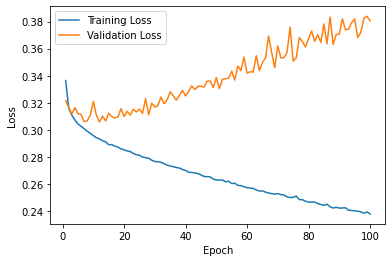

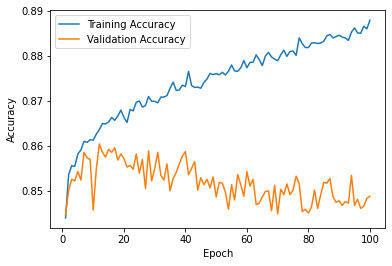

In [85]:
# Plot training loss and validation loss over epochs
# YOUR CODE HERE
plt.plot(range(1, num_epochs +1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs +1), history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
# YOUR CODE HERE
plt.plot(range(1, num_epochs +1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs +1), history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [86]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels
probability_predictions_nn = nn_model.predict(X_test_scaled)
class_label_predictions_nn = []

# YOUR CODE HERE
for i in range(0,len(y_test)):
    if probability_predictions_nn[i][0] >= 0.5:
        class_label_predictions_nn.append(1)
    else:
        class_label_predictions_nn.append(0)

In [87]:
# Compute accuracy and F1 score for the neural network and print the results

# YOUR CODE HERE
nn_accuracy_scr = accuracy_score(y_test, class_label_predictions_nn)
print('NN Accuracy score: {0}\n'.format(nn_accuracy_scr))
nn_f1_scr = f1_score(y_test, class_label_predictions_nn, average = "binary")
print('NN F1 score: {0}\n'.format(nn_f1_scr))

NN Accuracy score: 0.8458704329137243

NN F1 score: 0.6679894179894179



#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

<b> Answer: </b>
1. The architecture consists of input layer, 3 hidden layers with units: 64, 32, and 16 which are decreasing for model to learn as network size is decreased using relu. An output sigmoid unit was used since it is binary 0 or 1. Learning rate = 0.1 and 100 epochs are used for it to learn.
2. Training accuracy increased while training loss decreased. However after after 20 epochs, the validation loss increased while accuracy of validation remained around 0.85 which means there is some overfitting as it improved on training data and not validation data.
3. The neural network had an accuracy score of 0.8458704329137243 and an F1 score of 0.6679894179894179 on the test set. The accuracy was similar to the validation accuracy of approximately 0.85, so the test result was expected based on the training curves.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [89]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
# YOUR CODE HERE
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Model': [acc_score_best, f1_best],
    'Neural Network': [nn_accuracy_scr, nn_f1_scr]
})
print(results.to_string(index=False))

   Metric  Logistic Model  Neural Network
 Accuracy        0.849555        0.845870
 F1 Score        0.656381        0.667989


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

<b> Answer </b>:
1. The logistic regression accuracy score = 0.849555 and F1 score: 0.656381. While neural network had accuracy score = 0.845870 and F1 score = 0.667989. The accuracy score of neural network is lower than logistic regression while f1 is higher than logistic regression.
2. Not worth it due to it taking longer to train, multiple layer complexity of architecture, overfitting, and lower accuracy score. However, F1 score but it was minimal indicating neural network added complexity was not worth it.
3. If I were presenting this work to my company and their client I would recommend using logisitic regresison since it has higher accuracy score and similar f1 score. It is easy to implement and understand outputs. Incorrect predictions can deny loans to applicants that are eligible for loans or give loans to applicants that are not eligible for types of error that look for the specific client which is why it makes a prediction only but not the final decision.
4. With more time I would use techniques to work with class imbalance and different values for neural networks beyond what is learned in class, epoach, learning rates, to work with overfitting.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

<b> Answer </b>:
1. For data cleaning process, AI was used to brainstorm methods learned from course labs and assignments for what steps to take since that was one of the hardest part to understand part 3 and 4 for what features to look at. The assignment lab 2, 3, 4 were given to AI, to referesh on the concepts like winconization, data types, nan_counts, class imbalance for this assignment. The main questions were asked if my work makes sense, and to check syntax errors. The brainstorming process involved asking AI if this is correct, following labs/assignments work, asking AI to verify if this method for example class imabalance calculation counts['<=50K']/sum(counts.values) and counts['>50K']/sum(counts.values) is correct. Additionally an error during logisitic regression was about a warning, I asked AI to explain why it was wrong, it suggested that scaling is useful in that scenario similar to neural network for X_train, which was also used in development of foundational model. Most of the work was checking syntax, verifying work written in code and cross relating to previous labs to see if I am not going in the wrong direction. However, I do have to admit, due to the length of lab and limited time constraints, I did ask a lot of clarifying questions and syntax autofill based on what I learned before or what I need due to time constraint.
2. Part 3 and 4 required the most effort for me, I was stuck on this for about a week due to not being sure where to go next. AI boosted my progress forward when I gave it what I learned from previous lab (the content), and wrote down the label, features, and asked it should income_binary be a label, is logistic regression the right approach in this case since it is classification problem in a way and how KNN or decision tree might be an alternative. Every step in 3 and 4 parts, I prompted it by giving the code I wrote based on labs, previous assignments, and asked if it fits the requirements and feedback if anything else can be added. Furthermore, to increase speed due to being away this and last week, I described it syntax in those parts for what I want and it wrote down which was verified before running by me in part 3 and 4 mainly. Some prompts that were used were:
 * [Providing some files from my previous labs] this is how i learned working on missing data, outliers, and class imbalance. Explain the concepts to me first, and lets work on this step-by-step for the assignment starting with class imbalance, refresh the concept, I will provide you the code I write (I provided code from assignments and my own written version of that task) and asked if that is correct or are there any other better ways to approach that given task.
 * Verify my work and outputs [Pasting output from my code], and verify if that work is correct, matches requirement and what we have learned in class. If there is something wrong, explain in details about that certain task, some approaches that can be used to solve the error.
 * I ran into this warning for logisitic regression, I am not sure what this means, could you go in detail and explain why it is occuring and possible steps to work with it, including explanation.
 * Check my syntax [or] this is what I learned in assignments, can you help me write the code for this task (describing the task, with what I think should be done based on assignments). An example is F1 score: nn_f1_scr = f1_score(y_test, class_label_predictions_nn, average = "binary") print('NN F1 score: {0}\n'.format(nn_f1_scr)) to make the workflow faster.
3. I think it was more of a rushed approach for me, I made sure to check labs, assignments, and other material learned, included my thoughts/what the syntax I think should be or what should be done. AI was more of a tool that autofill the code or explained concepts that I was unsure why it is happening and for grammatical fixes.
4. I think it would be starting a bit earlier and practicing more data cleaning and preparation beyond class material. I was not at home last and this week leading to me falling behind a bit on work so it was a bit rushed. Also a bit less reliance of AI for brainstorming unless absolutely needed.